In [24]:
# import argparse

# def str_to_bool(value):
#     """Convert argument string to boolean."""
#     if isinstance(value, bool):
#         return value
#     if value.lower() in ('true', '1', 'yes', 'y'):
#         return True
#     elif value.lower() in ('false', '0', 'no', 'n'):
#         return False
#     else:
#         raise argparse.ArgumentTypeError("Boolean value expected (true/false or 1/0).")
        
# def int_or_str(val):
#     try:
#         return int(val)
#     except ValueError:
#         return val

# parser = argparse.ArgumentParser()
# parser.add_argument("--index", type=int_or_str, required=True, help="Filename index")
# parser.add_argument("--run_type", type=str, required=True, help="Filename index")
# # parser.add_argument("--seed", type=int, default=1, help="Filename index")
# # parser.add_argument("--loo", type=str_to_bool, required=True, help="Leave-one-out flag (true/false or 1/0)")

# parser.add_argument("--bn_weights_lambda_L2", type=float, default=1e-7, help="Adj matrix weights")
# parser.add_argument("--uniform_lambda_L2", type=float, default=1e-7, help="Y_full regularization")
# parser.add_argument("--cat_max_norm", type=float, default=100, help="Cat bias max norm")
# parser.add_argument("--global_bias_lambda_L2", type=float, default=0, help="Tot bias regularization")
# parser.add_argument("--cat_bias_lambda_L2", type=float, default=0, help="Tot bias regularization")
# parser.add_argument("--vae_scaling_KL", type=float, default=1e-2, help="Tot bias regularization")
# parser.add_argument("--global_bias_lambda_L1", type=float, default=0, help="Tot bias regularization")
# parser.add_argument("--cat_bias_lambda_L1", type=float, default=0, help="Tot bias regularization")
# parser.add_argument("--vae_prior_mu", type=float, default=0, help="Tot bias regularization")
# parser.add_argument("--vae_prior_sigma", type=float, default=1, help="Tot bias regularization")
# parser.add_argument("--adj_scaling_KL", type=float, default=0, help="Tot bias regularization")
# parser.add_argument("--adj_prior_mu", type=float, default=0, help="Tot bias regularization")
# parser.add_argument("--adj_prior_sigma", type=float, default=0.2, help="Tot bias regularization")
# parser.add_argument("--cat_bias_orthogonality_scaler", type=float, default=0, help="Tot bias regularization")
# parser.add_argument("--cat_b_adv", type=float, default=1.5, help="cat disc penalty weight b param")



# args = parser.parse_args()
# fn = str(args.index)
# run_type = str(args.run_type)
# fn += run_type
# # seed = args.seed
# # loo = args.loo
# bn_weights_lambda_L2 = args.bn_weights_lambda_L2
# uniform_lambda_L2 = args.uniform_lambda_L2
# cat_max_norm = args.cat_max_norm
# global_bias_lambda_L2 = args.global_bias_lambda_L2   
# cat_bias_lambda_L2 = args.cat_bias_lambda_L2
# vae_scaling_KL = args.vae_scaling_KL
# global_bias_lambda_L1 = args.global_bias_lambda_L1   
# cat_bias_lambda_L1 = args.cat_bias_lambda_L1
# vae_prior_mu = args.vae_prior_mu
# vae_prior_sigma = args.vae_prior_sigma
# adj_scaling_KL = args.adj_scaling_KL
# adj_prior_mu = args.adj_prior_mu
# adj_prior_sigma = args.adj_prior_sigma
# cat_bias_orthogonality_scaler = args.cat_bias_orthogonality_scaler
# cat_b_adv = args.cat_b_adv

# # python test_MAIN.py --index 1 --run_type A --bn_weights_lambda_L2 1e-7 --uniform_lambda_L2 1e-7 --cat_max_norm 100 --global_bias_lambda_L2 0 --cat_bias_lambda_L2 0 --vae_scaling_KL 1e-2 --global_bias_lambda_L1 0 --cat_bias_lambda_L1 0 --vae_prior_mu 0 --vae_prior_sigma 1 --adj_scaling_KL 0 --adj_prior_mu 0 --adj_prior_sigma 0.2 --cat_bias_orthogonality_scaler 0 --cat_b_adv 1.5


In [25]:
fn = '50'
run_type = 'E'
# seed = 3

# loo = True

# defaults
bn_weights_lambda_L2 = 1e-7
uniform_lambda_L2 = 1e-7
cat_max_norm = 100
global_bias_lambda_L2 = 0
cat_bias_lambda_L2 = 0
vae_scaling_KL = 1e-2
global_bias_lambda_L1 = 0
cat_bias_lambda_L1 = 0
vae_prior_mu = 0
vae_prior_sigma = 1
adj_scaling_KL = 0
adj_prior_mu = 0
adj_prior_sigma = 0.2
cat_bias_orthogonality_scaler = 0
cat_b_adv = 1.5

In [26]:
run_types = {'A': (1, True),
            'B': (3, True), 
            'C': (7, True), 
            'D': (10, True), 
            'E': (1, False)
            }
seed, loo = run_types[run_type]

In [27]:
visualize = False
mod_type = 'default'
subset = False
short_run = False
seed_split = 888

In [28]:
n_fraction = 0.2

train_frac, test_frac = 0.8, 0.2

a_scale = 10
b_scale = 2

# if mod_type not in ['default', 'tot_bias_scaler', 'global_bias_scaler', 'mu_bias_scaler', 
#                    'global_bias_regularizer', 'mu_bias_regularizer', 
#                    'standardized_weights']:
#     raise ValueError('Incorrect mod type specified')

# # assign file name accordingly

# fn = mod_type
# if mod_type == 'tot_bias_scaler':
#     fn += '_tot_a' + str(a_scale) + '_b' + str(b_scale)
# elif mod_type == 'global_bias_scaler':
#     fn += '_global_a' + str(a_scale) + '_b' + str(b_scale)
# elif mod_type == 'mu_bias_scaler':
#     fn += '_mu_a' + str(a_scale) + '_b' + str(b_scale)
# if subset:
#     fn += '_subset'
# if short_run:
#     fn += '_short_run'
# if loo:
#     fn += '_loo'



In [29]:
import os
from typing import Optional, Dict, List, Literal
import copy
import itertools
from tqdm import tqdm
import gc
import math

import pandas as pd
import numpy as np
import scanpy as sc

from scipy import stats
from sklearn.metrics import normalized_mutual_info_score
import torch
import scanpy as sc
import pandas as pd
from typing import List, Literal
import torch
from geomloss import SamplesLoss
import torch.nn as nn

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns

from sklearn.model_selection import train_test_split

In [30]:
import sys
sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS import io

# from scLEMBAS.model.train_dev_mu_regularizer import TrainSC as TrainSCDevMu
# from scLEMBAS.model.train_dev_weights_standard import TrainSC as TrainSCDevWstandard
from scLEMBAS.model.train import TrainSC
from scLEMBAS.preprocess import discriminator_weight_curve, embed_tf_activity, get_alignment_score


# from scLEMBAS.model.scl_dev_tot_scaler import SignalingModel as SignalingModelDevTot
# from scLEMBAS.model.scl_dev_global_scaler import SignalingModel as SignalingModelDevGlobal
# from scLEMBAS.model.scl_dev_mu_scaler import SignalingModel as SignalingModelDevMu
# from scLEMBAS.model.scl_dev_weights_standard import SignalingModel as SignalingModelDevWstandard
from scLEMBAS.model.scl import SignalingModel

SM = {'default': SignalingModel}#, 
#      'tot_bias_scaler': SignalingModelDevTot, 
#      'global_bias_scaler': SignalingModelDevGlobal, 
#      'mu_bias_scaler': SignalingModelDevMu, 
#      'global_bias_regularizer': SignalingModel, 
#      'mu_bias_regularizer': SignalingModel,
#      'standardized_weights': SignalingModelDevWstandard # initializes weights much larger
#      }

TR = {'default': TrainSC}#, 
#      'tot_bias_scaler': TrainSC, 
#      'global_bias_scaler': TrainSC, 
#      'mu_bias_scaler': TrainSC, 
#      'global_bias_regularizer': TrainSC, # by default, regularizes global bias
#       'mu_bias_regularizer': TrainSCDevMu, 
#       'standardized_weights': TrainSCDevWstandard 
#      }

sys.path.insert(1, '/home/hmbaghda/Projects/scLEMBAS/notebooks/Kang_2017/')
from Kang_utils import (rev_stim, stim_map, rev_stim_map, adata_dimviz_bias, clear_memory,
                        get_prediction, adata_dimviz_prediction, prepare_for_metrics, get_loss)

In [31]:
n_cores = 12
os.environ["OMP_NUM_THREADS"] = str(n_cores)
os.environ["MKL_NUM_THREADS"] = str(n_cores)
os.environ["OPENBLAS_NUM_THREADS"] = str(n_cores)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(n_cores)
os.environ["NUMEXPR_NUM_THREADS"] = str(n_cores)

data_path = '/nobackup/users/hmbaghda/scLEMBAS/analysis'
device = "cuda" if torch.cuda.is_available() else "cpu"

In [32]:
adata = sc.read_h5ad(os.path.join(data_path, 'processed', 'kang_expr_scored.h5ad'))
sn_ppis = pd.read_csv(os.path.join(data_path, 'processed', 'Kang_sn_ppis.csv'), index_col = 0)

tf_adata = io.read_tfad(os.path.join(data_path, 'processed', 'Kang_tf_activity.h5ad'))
tf_adata.obs['condition'] = tf_adata.obs['stim'].astype(str) + '^' + tf_adata.obs['seurat_annotations'].astype(str)

# ensures correct order of test data
# note, this already saved in order, matching the mod.y_out columns
tf_adata = tf_adata[:, sorted(tf_adata.var_names)] 

source_label = 'source_genesymbol'
target_label = 'target_genesymbol'
weight_label = 'mode_of_action'
stimulation_label = 'consensus_stimulation'
inhibition_label = 'consensus_inhibition'

/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 1. Create a novel train-test split:

In [33]:
def ood_split(tf_adata, 
             train_frac: float, 
              stim_col: str = 'stim', 
              context_col: str = 'seurat_annotations', 
              context_bins: Optional[pd.DataFrame] = None, 
              context_bins_frac: float = 1, 
             max_iter: int = 1000, 
             seed: int = 888, 
             deviation_thresh: float = 0.025, 
             include_train_cond: Optional[Dict[str, List]] = None):
    """Generate an OOD train test split, where both the condition data and the single-cells have approximately
    the specified split.
    
    Rules: 
    1. cell split and condition split is similar (conditions is exactly the split, 
    cells is approximate by deviation_thresh)
    2. Each component (condition_cols) of the condition is seen atleast once in the training
    3. Each of the stimulation column is seen atleast once in the test
    4. The test context (cell type) needs to contain atleast one from context_frac of the total context_bins 

    Parameters
    ----------
    tf_adata : 
        AnnData object of TF activity
    train_frac : float
        the fraction of the data going to training
    stim_col : List[str]
        the metadata column defining the stimulation condition
    context_col: str
        the metadata column of the context, together with stim col defines the OOD split
    context_bins: Optional[pd.DataFrame]
        binning of the context categories, by default None
    context_bins_frac: float
        the number of bins that should be included in the test data from the context bins
    max_iter : int, optional
        total iterations to try to identify a suitable split, by default 1000
    seed : int, optional
        random state variable, by default 888
    deviation_thresh : float, optional
        extent to which to allow the single-cell split to deviate from the specified `train_frac split`, by default 0.025
    include_train_cond : Optional[Dict[str, List]]
        a dictionary with keys for each of stim_col and context_col and keys as a list that represents a subset
        of values in that column that must be included in the training set. 
    """
    test_frac = 1 - train_frac

    condition_cols = [stim_col, context_col]
    condition_combs = tf_adata.obs[condition_cols].apply(lambda row: '^'.join(row.astype(str)), axis=1)
    unique_conditions = condition_combs.drop_duplicates(keep = 'first', inplace = False).tolist()

    # define the conditions for stopping
    train_frac_deviation = np.inf
    zero_shot_bool = False

    test_stim = False
    n_stims = tf_adata.obs['stim'].nunique()

    if context_bins is not None:
        if context_bins_frac > 1 or context_bins_frac < 0:
            raise ValueError('The fraction must be between 0 and 1')
        n_contexts = np.floor(context_bins_frac*context_bins.nunique())
        context_present = False
    else:
        context_present = True

    if include_train_cond is not None:
        if sorted(set(include_train_cond).intersection(condition_cols)) != sorted(condition_cols):
            raise ValueError('Keys for `include_train_cond` must be the same as `condition_cols`')
        for cond, cond_vals in include_train_cond.items():
            if not set(cond_vals).issubset(tf_adata.obs[cond].tolist()):
                raise ValueError('The conditions to include in training for ' + cond + ' are not present in the metadata.')
        ict_bool = False
    else:
        ict_bool = True

    counter = 0
    while (train_frac_deviation > deviation_thresh or not zero_shot_bool or not ict_bool or not test_stim or not context_present) and (counter < max_iter):
        # ood at categorical level
        train_cond, test_cond = train_test_split(unique_conditions, test_size = test_frac, random_state = seed + counter, shuffle = True)
        train_cells = condition_combs[condition_combs.isin(train_cond)].index.tolist()
        test_cells = condition_combs[condition_combs.isin(test_cond)].index.tolist()

        train_frac_actual = len(train_cells)/tf_adata.shape[0]
        train_frac_deviation = abs(train_frac_actual - train_frac)

        # ensure that all individual conditions are seen atleast once (it's the combination of conditions that's unique)
        train_cond_map = {}
        for idx, cond in enumerate(condition_cols):
            train_cond_map[cond] = {tc.split('^')[idx] for tc in train_cond}

        test_cond_map = {}
        for idx, cond in enumerate(condition_cols):
            test_cond_map[cond] = {tc.split('^')[idx] for tc in test_cond}

        zero_shots = [len(test_cond_map[cond].difference(train_cond_map[cond])) for cond in condition_cols]    
        zero_shot_bool = all(value == 0 for value in zero_shots)

        test_stim = (len(test_cond_map['stim']) == n_stims)


        if context_bins is not None:
            context_present = context_bins.loc[list(test_cond_map[context_col])].nunique() >= n_contexts

        if include_train_cond is not None:
            ict_conds = [len(include_train_cond[cond].difference(cond_vals)) for cond, cond_vals in train_cond_map.items()]
            ict_bool = any(value == 0 for value in ict_conds)

        counter += 1

    if counter < max_iter:
        return train_cells, test_cells, train_cond, test_cond
    else:
        return None, None, None, None

In [34]:
contingency_table = pd.crosstab(tf_adata.obs['stim'], tf_adata.obs['seurat_annotations'], 
                                margins=True, margins_name="Total")
contingency_table = contingency_table.T.sort_values(by = 'Total').T
bins = pd.qcut(contingency_table.T.Total, q = 4, labels = False)

In [35]:
if not loo:
    condition_cols = ['stim', 'seurat_annotations']
    train_cells, test_cells, train_cond, test_cond = ood_split(tf_adata,
                                                                       train_frac = 0.8,
                                                                       stim_col = condition_cols[0], 
                                                                       context_col = condition_cols[1], 
                                                                       context_bins = bins, 
                                                                       context_bins_frac = 1, 
                                                                       max_iter = 1000, 
                                                                       seed = seed_split, 
                                                                       deviation_thresh = 0.025, 
                                                                       include_train_cond = None)

    test_conds = test_cond
else:
    unique_conditions = sorted(set(tf_adata.obs.condition))

    if run_type in ['A', 'B']:
        unique_conditions.remove('CTRL^DC')
        unique_conditions.insert(0, 'CTRL^DC')
    elif run_type in ['C', 'D']:
        unique_conditions.remove('STIM^DC')
        unique_conditions.insert(0, 'STIM^DC')  
    
    test_cond = [unique_conditions[0]]
    train_cond = sorted(set(unique_conditions).difference(test_cond))
    
    test_conds = test_cond
    
    test_cells = tf_adata.obs[tf_adata.obs.condition.isin(test_cond)].index.tolist()
    train_cells = tf_adata.obs[tf_adata.obs.condition.isin(train_cond)].index.tolist()

In [36]:
condition_proportions = tf_adata.obs['condition'].value_counts()
condition_proportions.loc[train_cond].sort_values(ascending = True)

condition
CTRL^Eryth             23
STIM^Eryth             32
STIM^pDC               81
CTRL^Mk               115
STIM^Mk               121
CTRL^B Activated      185
STIM^B Activated      203
STIM^DC               214
CTRL^DC               258
CTRL^T activated      300
STIM^NK               321
STIM^T activated      333
CTRL^B                407
STIM^CD8 T            462
CTRL^CD16 Mono        507
STIM^B                571
CTRL^CD4 Memory T     859
STIM^CD4 Naive T     1526
STIM^CD14 Mono       2147
CTRL^CD14 Mono       2215
Name: count, dtype: int64

In [37]:
condition_proportions.loc[test_cond].sort_values(ascending = True)

condition
CTRL^pDC              51
CTRL^NK              298
CTRL^CD8 T           352
STIM^CD16 Mono       537
STIM^CD4 Memory T    903
CTRL^CD4 Naive T     978
Name: count, dtype: int64

# 2. Subset data

In [38]:
if subset:
    adata_all = adata.copy()
    tf_adata_all = tf_adata.copy()
    train_cells_all = copy.deepcopy(train_cells)

    tf_adata_train = tf_adata_all[train_cells_all, :]
    condition_proportions = tf_adata_train.obs['condition'].value_counts(normalize=True)
    total_cells = tf_adata_train.n_obs
    n_subset = int(n_fraction * total_cells)

    # number of cells to sample per condition
    sample_sizes = (condition_proportions * n_subset).round().astype(int)

    # Subset the cells for each condition
    subset_indices = []
    for condition, n_cells in sample_sizes.items():
        condition_indices = tf_adata_train.obs[tf_adata_train.obs['condition'] == condition].index
        np.random.seed(seed_split)
        sampled_condition_indices = np.random.choice(condition_indices, size=n_cells, replace=False)
        subset_indices.extend(sampled_condition_indices)

    n_train = len(subset_indices)
    train_cells = copy.deepcopy(subset_indices)
    print('The number of train cells has been reduced from {} to {}'.format(tf_adata_train.shape[0], 
                                                                           n_train))

    # include the test data
    subset_indices.extend(test_cells)
    tf_adata = tf_adata_all[subset_indices,:]
    adata = adata_all[subset_indices,:]
    


In [39]:
tf_adata

View of AnnData object with n_obs × n_vars = 13999 × 240
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'stim', 'seurat_annotations', 'n_genes', 'gene_clusters', 'TF_clusters', 'condition'
    uns: 'TF_clusters_colors', 'leiden', 'neighbors', 'pca', 'seurat_annotations_colors', 'stim_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [40]:
condition_proportions = tf_adata.obs['condition'].value_counts()
condition_proportions.loc[train_cond].sort_values(ascending = True)

condition
CTRL^Eryth             23
STIM^Eryth             32
STIM^pDC               81
CTRL^Mk               115
STIM^Mk               121
CTRL^B Activated      185
STIM^B Activated      203
STIM^DC               214
CTRL^DC               258
CTRL^T activated      300
STIM^NK               321
STIM^T activated      333
CTRL^B                407
STIM^CD8 T            462
CTRL^CD16 Mono        507
STIM^B                571
CTRL^CD4 Memory T     859
STIM^CD4 Naive T     1526
STIM^CD14 Mono       2147
CTRL^CD14 Mono       2215
Name: count, dtype: int64

In [41]:
condition_proportions.loc[test_cond].sort_values(ascending = True)

condition
CTRL^pDC              51
CTRL^NK              298
CTRL^CD8 T           352
STIM^CD16 Mono       537
STIM^CD4 Memory T    903
CTRL^CD4 Naive T     978
Name: count, dtype: int64

# 3. Run training

In [42]:
def generate_lr_params(n_epochs, max_lr, lr_scaling_factor = 10, lr_decay = 0.9):
    lr_period = 3 if n_epochs < 500 else 4
    lr_params = {'max_epochs': n_epochs, 
                 'maximum_learning_rate': max_lr, 
                 'minimum_learning_rate': max_lr/lr_scaling_factor,
                 'lr_restart_epoch': int(n_epochs/lr_period), 
                 'reset_optimizer_epoch': int(n_epochs/3), 
                'lr_decay': lr_decay, 
                 'lr_restart_factor': 1, 
                 'warmup_epochs': int(n_epochs/10)}
    return lr_params

def generate_discriminator_params(n_epochs, max_lr, discriminator_penalty_weight, 
                                  lr_scaling_factor = 10, lr_decay = 0.9):
    general_params = generate_lr_params(n_epochs, max_lr, lr_scaling_factor = lr_scaling_factor, 
                                        lr_decay = lr_decay)
    
    keys_to_keep = ['maximum_learning_rate', 'minimum_learning_rate', 'lr_restart_epoch', 
                   'warmup_epochs', 'lr_decay', 'reset_optimizer_epoch']
    discriminator_params = {'batch_momentum': 0.01,
                            'layer_norm': False,
                            'dropout_rate': 0.1,
                            'activation_fn': nn.LeakyReLU,
                            'n_hidden_nodes': [768, 512, 256],
                            'lr_restart_factor': 1,
                            'optimizer': torch.optim.Adam,
                            'discriminator_lambda_L2': 1e-3,
                            'discriminator_penalty_weight': discriminator_penalty_weight}
    discriminator_params = {**discriminator_params, 
                           **{k:v for k,v in general_params.items() if k in keys_to_keep}}
    
    return discriminator_params

In [43]:
# hyperparameters
n_layers_vae = 2
n_nodes = len(set(sn_ppis[source_label].tolist() + sn_ppis[target_label].tolist()))
vae_n_hidden_nodes = list(np.round(np.linspace(adata.shape[1], n_nodes, n_layers_vae + 2)).astype(int)[1:-1])

# linear scaling of inputs/outputs
projection_amplitude_in = 10
projection_amplitude_out = 1

# other parameters
bionet_params = {'target_steps': 100, 
                 'max_steps': 120, 
                 'exp_factor':50, 
                 'tolerance': 1e-5, 
                 'leak':1e-2}
vae_params = {'vae_batch_momentum': 0.01, 'vae_layer_norm': False, 'vae_dropout_rate': 0.1,
              'vae_activation_fn': nn.LeakyReLU,
              'vae_n_hidden_nodes': vae_n_hidden_nodes, 
              'vae_var_min': 1e-4}
bionet_params = {**bionet_params, **vae_params}


bionet_params['cat_max_norm'] = cat_max_norm
# if mod_type in ['default', 'total_bias_scaler', 'mu_bias_regularizer', 'mu_bias_scaler']: 
#     bionet_params['cat_max_norm'] = cat_max_norm
# elif mod_type in ['global_bias_scaler', 'global_bias_regularizer']:
#     bionet_params['cat_max_norm'] = 50 # since scaling global bias, need to separately scale categorical with the regularization

    
if mod_type in ['tot_bias_scaler', 'global_bias_scaler', 'mu_bias_scaler']:
    bionet_params['signaling_weights_scaler'] = a_scale
    if mod_type == 'tot_bias_scaler':
        bionet_params['bias_tot_scaler'] = b_scale
    elif mod_type == 'global_bias_scaler':
        bionet_params['bias_global_scaler'] = b_scale
    elif mod_type == 'mu_bias_scaler':
        bionet_params['bias_mu_scaler'] = b_scale

In [44]:
# training parameters
other_params_default = {'network_noise_scale': 10, 'gradient_noise_scale': 1e-9, 
               'test_batch_size': np.nan}
spectral_radius_params = {'n_probes_spectral': 5, 
                          'power_steps_spectral': 5, #50, 
                          'subset_n_spectral': 5} #10}

if mod_type != 'standardized_weights':
    target_spectral_radius = 0.9
else: 
    target_spectral_radius = 30

regularization_params_default = {'input_lambda_L2': 0, # doesn't matter if setting the requires grad to False
                         'bn_weights_lambda_L2': bn_weights_lambda_L2, #1e-7, 
                         'global_bias_lambda_L2': global_bias_lambda_L2, #0, # don't incorporate because of KL divergence
                                 'cat_bias_lambda_L2': cat_bias_lambda_L2,
                         'output_weights_lambda_L2': 1e-7,
                         'output_bias_lambda_L2': 1e-7,
                         'moa_lambda_L1': 1e2,  
                         'uniform_lambda_L2': uniform_lambda_L2,#, 1e-7,
                         'uniform_min': 0,
                         'uniform_max': 1, 
                         'spectral_loss_factor': 1e-6,
                        'vae_lambda_l2': 1e-7, 
                        'vae_scaling_KL': vae_scaling_KL, #1e-2
                               'global_bias_lambda_L1': global_bias_lambda_L1, 
                                'cat_bias_lambda_L1': cat_bias_lambda_L1,
                                'vae_prior_mu': vae_prior_mu, 
                                'vae_prior_sigma': vae_prior_sigma, 
                                'adj_scaling_KL': adj_scaling_KL, 
                                 'adj_prior_mu': adj_prior_mu, 
                                 'adj_prior_sigma': adj_prior_sigma, 
                                 'cat_bias_orthogonality_scaler': cat_bias_orthogonality_scaler
                                }


# if mod_type.endswith('_regularizer'):
#     regularization_params_default['bn_weights_lambda_l2'] = 1e-12 # decrease adj matrix regularization
#     regularization_params_default['global_bias_lambda_L2'] = 1e-5 # increase global bias regularization

In [45]:
if not short_run:
    max_penalty_weight = 7.75
#     cat_b_adv = 0.6
    max_epochs = 600
else:
    max_penalty_weight = 8
#     cat_b_adv = 1.5
    max_epochs = 250 
    
if subset:
#     batch_factor = 1 if n_fraction <= 0.2 else 3
#     train_batch = int(np.round(n_train/batch_factor))
    batch_factor = 2 if n_fraction <= 0.1 else 3
    train_batch = int(np.round(n_train/batch_factor))
else:
    train_batch = 1024

# max_epochs = 10
max_lr = 0.001



cat_discriminator_penalty_weight = discriminator_weight_curve(n_epochs = max_epochs,
                                                          min_penalty_weight = 0.1,
                                                          max_penalty_weight = max_penalty_weight,
                                                          a = 1,
                                                          b = cat_b_adv, 
                                                          curve_type = 'power')

pert_discriminator_penalty_weight = discriminator_weight_curve(n_epochs = max_epochs,
                                                               min_penalty_weight = 0.1,
                                                               max_penalty_weight = 30,
                                                               a = 1,
                                                               b = 1.5, 
                                                               curve_type = 'power')


lr_params = generate_lr_params(n_epochs = max_epochs, max_lr = max_lr, lr_scaling_factor = 10, lr_decay = 0.9)
cat_discriminator_params = generate_discriminator_params(n_epochs = max_epochs, max_lr = max_lr, 
                      discriminator_penalty_weight = cat_discriminator_penalty_weight, 
                      lr_scaling_factor = 10, lr_decay = 0.9)

pert_discriminator_params = cat_discriminator_params.copy()
pert_discriminator_params['discriminator_penalty_weight'] = pert_discriminator_penalty_weight

regularization_params = regularization_params_default.copy()
other_params = {**other_params_default,
                **{'train_batch_size': train_batch,
                   'validation_batch_size': np.nan}}
training_params = {**lr_params, **other_params, **regularization_params, **spectral_radius_params}


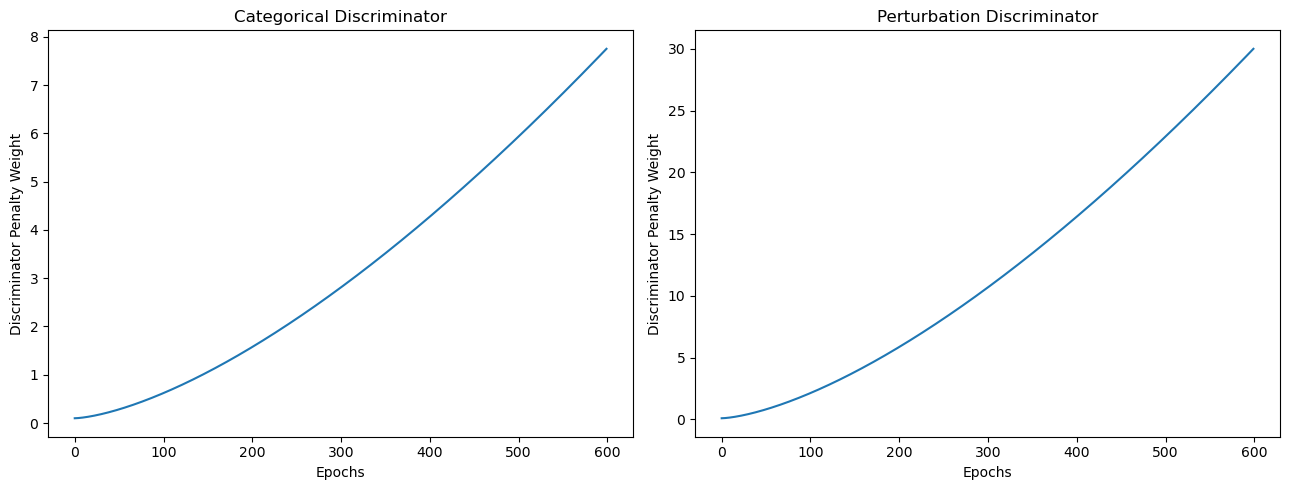

In [46]:
fig, ax = plt.subplots(ncols = 2, figsize = (13,5))
sns.lineplot(cat_discriminator_params['discriminator_penalty_weight'], ax = ax[0])
ax[0].set_title('Categorical Discriminator')

sns.lineplot(pert_discriminator_params['discriminator_penalty_weight'], ax = ax[1])
ax[1].set_title('Perturbation Discriminator')

for i in range(2):
    ax[i].set_xlabel('Epochs')
    ax[i].set_ylabel('Discriminator Penalty Weight')
    
fig.tight_layout();


In [47]:
mod = SM[mod_type](net = sn_ppis,
                 X_in = pd.DataFrame(tf_adata.obs.stim.cat.codes, columns = ['IFNB1']),
                 y_out = tf_adata.to_df().copy(), 
                 expr = adata.to_df().copy(), 
                 covariates = tf_adata.obs.copy(),
                 categorical_covariate_keys = ['seurat_annotations'],
                 projection_amplitude_in = projection_amplitude_in, 
                 projection_amplitude_out = projection_amplitude_out,
                 weight_label = weight_label, source_label = source_label, target_label = target_label,
                 bionet_params = bionet_params, 
                 dtype = torch.float32, device = device, seed = seed)

mod.input_layer.weights.requires_grad = False # don't learn scaling factors for the ligand input concentrations
mod.signaling_network.prescale_weights(target_radius = target_spectral_radius) # spectral radius

In [48]:
trainer = TR[mod_type](mod = mod,
                   prediction_optimizer = torch.optim.Adam,
                   prediction_loss_fn = SamplesLoss("sinkhorn", p=2, blur=0.05).to(device), #torch.nn.MSELoss(reduction='mean'),
                  cat_discriminator_params = cat_discriminator_params,
                       pert_discriminator_params = pert_discriminator_params,
                   hyper_params = training_params,
                   train_split = {'train': train_cells, 'test': test_cells, 'validation': None}, 
                   train_seed = seed, 
                   track_test = False,
                   track_validation = False)

# Start

In [49]:
class WeightUpdateMonitor:
    def __init__(self, model, atol=1e-6):
        self.model = model
        self.atol = atol
        self._saved_weights = {}

    def save(self):
        """Save a snapshot of current weights and gradients (if exist)."""
        self._saved_weights = {
            name: param.detach().clone()
            for name, param in self.model.named_parameters()
        }
        self._saved_grads = {
            name: param.grad.detach().clone() if param.grad is not None else None
            for name, param in self.model.named_parameters()
        }

    def check(self, verbose=True):
        """Report norm deltas only when weight or gradient has changed."""
        changed = False
        for name, param in self.model.named_parameters():
            old_weight = self._saved_weights[name]
            new_weight = param.detach()
            delta = new_weight - old_weight
            delta_norm = delta.norm().item()
            weight_changed = delta_norm > self.atol
            changed = changed or weight_changed

            # Check gradient
            grad = param.grad
            grad_old = self._saved_grads.get(name, None)
            grad_changed = False
            grad_norm = None

            if grad is not None:
                grad_norm = grad.norm().item()
                if grad_old is None:
                    grad_changed = True
                else:
                    grad_changed = not torch.allclose(grad, grad_old, atol=self.atol)


            if verbose and (weight_changed or grad_changed):
                print(f"{name}:")
                if weight_changed:
                    print(f" weight norm change: {delta_norm:.3e}")
                if grad_changed:
                    print(f"grad norm:   {grad_norm:.3e}")
            if not verbose:
                return changed


In [115]:
pert_discriminator_params['discriminator_penalty_weight'] = 100.0
# pert_discriminator_params['discriminator_penalty_weight'] = pert_discriminator_penalty_weight

In [116]:
from scLEMBAS.model.train import *

mod = SM[mod_type](net = sn_ppis,
                 X_in = pd.DataFrame(tf_adata.obs.stim.cat.codes, columns = ['IFNB1']),
                 y_out = tf_adata.to_df().copy(), 
                 expr = adata.to_df().copy(), 
                 covariates = tf_adata.obs.copy(),
                 categorical_covariate_keys = ['seurat_annotations'],
                 projection_amplitude_in = projection_amplitude_in, 
                 projection_amplitude_out = projection_amplitude_out,
                 weight_label = weight_label, source_label = source_label, target_label = target_label,
                 bionet_params = bionet_params, 
                 dtype = torch.float32, device = device, seed = seed)

mod.input_layer.weights.requires_grad = False # don't learn scaling factors for the ligand input concentrations
mod.signaling_network.prescale_weights(target_radius = target_spectral_radius) # spectral radius

trainer = TR[mod_type](mod = mod,
                   prediction_optimizer = torch.optim.Adam,
                   prediction_loss_fn = SamplesLoss("sinkhorn", p=2, blur=0.05).to(device), #torch.nn.MSELoss(reduction='mean'),
                  cat_discriminator_params = cat_discriminator_params,
                       pert_discriminator_params = pert_discriminator_params,
                   hyper_params = training_params,
                   train_split = {'train': train_cells, 'test': test_cells, 'validation': None}, 
                   train_seed = seed, 
                   track_test = False,
                   track_validation = False)

self = trainer

In [117]:
monitor = {'Model': WeightUpdateMonitor(model = self.mod), 
           'CatDiscriminator':WeightUpdateMonitor(model = self.cat_discriminator['discriminators']['seurat_annotations']), 
          'PertDiscriminator': WeightUpdateMonitor(model = self.pert_discriminator['discriminator'])}

for update_monitor in monitor.values():
    update_monitor.save()
for model_type, update_monitor in monitor.items():
    print(model_type)
    update_monitor.check()
    print()

Model

CatDiscriminator

PertDiscriminator



In [118]:
start_time = time.time()
self.mod.signaling_network.implement_mask() # shouldn't be necessary bc called in signaling_network init

torch.autograd.set_detect_anomaly(True)

for e in trange(self.hyper_params['max_epochs']):
    break

  0%|                                                   | 0/600 [00:00<?, ?it/s]


In [119]:
cur_lr = self.prediction_optimizer.param_groups[0]['lr']
self.cat_discriminator['_cur_lr'] = self.cat_discriminator['optimizer'].param_groups[0]['lr']
self.pert_discriminator['_cur_lr'] = self.pert_discriminator['optimizer'].param_groups[0]['lr']
cur_catdisc_lambda = self.cat_discriminator['params']['discriminator_penalty_weight'][e]
cur_pertdisc_lambda = self.pert_discriminator['params']['discriminator_penalty_weight'][e]
print(cur_pertdisc_lambda)

cur_vae_loss, cur_kl_loss, disc_loss_tot_train, disc_loss_pred_train, disc_param_loss = [], [], [], [], []

# iterate through batches
if self.mod.seed:
    utils.set_seeds(self.mod.seed + e)

100.0


In [127]:

for batch, (X_in_, y_out_, covariates_idx_, expr_) in enumerate(self.train_dataloader):
    if batch == 1:
        break

In [128]:
self.mod.train()
for mod_discriminator in self.cat_discriminator['discriminators'].values():
    mod_discriminator.train()
self.pert_discriminator['discriminator'].train()


self.prediction_optimizer.zero_grad()
self.cat_discriminator['optimizer'].zero_grad()
self.pert_discriminator['optimizer'].zero_grad()

X_in_, y_out_, covariates_idx_ = X_in_.to(self.mod.device), y_out_.to(self.mod.device), covariates_idx_.to(self.mod.device)

######################## Forward Pass ########################
X_full = self.mod.input_layer(X_in_) # transform to full network with ligand input concentrations
utils.set_seeds(self.mod.seed + self.mod._gradient_seed_counter)
network_noise = torch.randn(X_full.shape, device = X_full.device)
X_full = X_full + (self.hyper_params['network_noise_scale'] * cur_lr * network_noise) # randomly add noise to signaling network input, makes model more robust
Y_full, bias_terms = self.mod.signaling_network(X_full = X_full, 
                                                 covariates_idx = covariates_idx_, 
                                                 expr = expr_) # train signaling network weights
bias_global, bias_mu, bias_log_sigma_squared = bias_terms

Y_hat = self.mod.output_layer(Y_full)

######################## Categorical DISCRIMINATOR ########################
# discriminator prediction and loss
cat_discriminator_loss_accuracy = torch.tensor(0, device = self.mod.device, dtype = self.mod.dtype)
for cat_group_idx, (cat, discriminator) in enumerate(self.cat_discriminator['discriminators'].items()):
    bias_global_prediction = discriminator(bias_global.detach()) # predicted logits
    # if don't use retain_graph = True, then use bias_global.detach() here

    target = covariates_idx_[:, cat_group_idx]
    if discriminator.n_labels == 2:
        target = target.to(self.mod.dtype).unsqueeze(1)

    cat_discriminator_loss_accuracy += discriminator.loss_fn(bias_global_prediction, target)   

# discriminator regularization
cat_discriminator_reg = torch.tensor(0, device = self.mod.device, dtype = self.mod.dtype)
for discriminator in self.cat_discriminator['discriminators'].values():
    cat_discriminator_reg += discriminator.L2_reg(self.cat_discriminator['params']['discriminator_lambda_L2'])
cat_discriminator_loss = cat_discriminator_loss_accuracy + cat_discriminator_reg

# discriminator optimization
# NOTE: discriminator is optimized prior to adverserial training (and loss re-calculated)
cat_discriminator_loss.backward() # if bias global is not detached, need to set retain_graph = True here
self.cat_discriminator['optimizer'].step()

# freeze discriminator (to prevent updating discriminator gradients when calling discriminator while 
# training generator adverserially below)
for discriminator in self.cat_discriminator['discriminators'].values():
    freeze_model(model = discriminator)

# NOTE: 
# a good adverserial check here is to see if the vae (and all self.mod) param gradients are still 0, 
# as the backward pass for prediction has not yet been called; when using the retain_graph = True
# and not calling bias_global.detach() above, the gradients from calculating the discriminator loss
# on bias global were leaking into the generator portion

In [129]:
for model_type, update_monitor in monitor.items():
    print(model_type)
    update_monitor.check()
    print()
for update_monitor in monitor.values():
    update_monitor.save()

Model

CatDiscriminator
classifier.0.fc_layers.FC Layer 0.linear.weight:
 weight norm change: 1.176e-01
grad norm:   1.857e+00
classifier.0.fc_layers.FC Layer 0.linear.bias:
 weight norm change: 2.756e-03
classifier.0.fc_layers.FC Layer 0.batch normalization.weight:
 weight norm change: 2.016e-03
grad norm:   1.563e-02
classifier.0.fc_layers.FC Layer 0.batch normalization.bias:
 weight norm change: 2.023e-03
grad norm:   1.357e-02
classifier.0.fc_layers.FC Layer 1.linear.weight:
 weight norm change: 4.587e-02
grad norm:   7.781e-01
classifier.0.fc_layers.FC Layer 1.linear.bias:
 weight norm change: 2.255e-03
classifier.0.fc_layers.FC Layer 1.batch normalization.weight:
 weight norm change: 1.635e-03
grad norm:   1.423e-02
classifier.0.fc_layers.FC Layer 1.batch normalization.bias:
 weight norm change: 1.674e-03
grad norm:   1.186e-02
classifier.0.fc_layers.FC Layer 2.linear.weight:
 weight norm change: 2.678e-02
grad norm:   5.475e-01
classifier.0.fc_layers.FC Layer 2.linear.bias:
 wei

In [130]:
######################## Perturbation DISCRIMINATOR ########################
# same implementation as categorical discriminator currently
# discriminator prediction and loss
bias_global_prediction = self.pert_discriminator['discriminator'](bias_global.detach()) # predicted logits

if self.pert_discriminator['discriminator'].n_labels != 2:
    target = X_in_.argmax(dim=1)
    # differentiate between rows with no perturbation and rows with perturbation at column 1 (index 0)
    no_pert = X_in_.sum(dim=1) == 0  
    target[no_pert] = self.pert_discriminator['discriminator'].n_labels - 1 # -1 for indexing
else:
    target = X_in_#.long().reshape(-1)


pert_discriminator_loss_accuracy = self.pert_discriminator['discriminator'].loss_fn(bias_global_prediction, target)   

# discriminator regularization
pert_discriminator_reg = self.pert_discriminator['discriminator'].L2_reg(self.pert_discriminator['params']['discriminator_lambda_L2'])
pert_discriminator_loss = pert_discriminator_loss_accuracy + pert_discriminator_reg

# discriminator optimization
pert_discriminator_loss.backward() # if bias global is not detached, need to set retain_graph = True here
self.pert_discriminator['optimizer'].step()

# freeze discriminator
freeze_model(model = self.pert_discriminator['discriminator'])

In [131]:
for model_type, update_monitor in monitor.items():
    print(model_type)
    update_monitor.check()
    print()
for update_monitor in monitor.values():
    update_monitor.save()

Model

CatDiscriminator

PertDiscriminator
classifier.0.fc_layers.FC Layer 0.linear.weight:
 weight norm change: 1.167e-01
grad norm:   9.912e-01
classifier.0.fc_layers.FC Layer 0.linear.bias:
 weight norm change: 2.762e-03
grad norm:   5.532e-04
classifier.0.fc_layers.FC Layer 0.batch normalization.weight:
 weight norm change: 1.997e-03
grad norm:   8.193e-03
classifier.0.fc_layers.FC Layer 0.batch normalization.bias:
 weight norm change: 2.010e-03
grad norm:   7.051e-03
classifier.0.fc_layers.FC Layer 1.linear.weight:
 weight norm change: 4.555e-02
grad norm:   4.177e-01
classifier.0.fc_layers.FC Layer 1.linear.bias:
 weight norm change: 2.255e-03
grad norm:   9.244e-04
classifier.0.fc_layers.FC Layer 1.batch normalization.weight:
 weight norm change: 1.667e-03
grad norm:   7.036e-03
classifier.0.fc_layers.FC Layer 1.batch normalization.bias:
 weight norm change: 1.659e-03
grad norm:   6.229e-03
classifier.0.fc_layers.FC Layer 2.linear.weight:
 weight norm change: 2.715e-02
grad norm

In [132]:






######################## LEMBAS and generator ########################
# reconstruction loss
prediction_loss = self.prediction_loss_fn(y_out_, Y_hat)

# lembas regularization
sign_reg = self.mod.signaling_network.sign_regularization(lambda_L1 = self.hyper_params['moa_lambda_L1']) # incorrect MoA
#             ligand_reg = self.mod.ligand_regularization(lambda_L2 = self.hyper_params['ligand_lambda_L2']) # ligand biases
stability_loss, spectral_radius = self.mod.signaling_network.get_SS_loss(Y_full = Y_full.detach(), spectral_loss_factor = self.hyper_params['spectral_loss_factor'],
                                                                    subset_n = self.hyper_params['subset_n_spectral'], n_probes = self.hyper_params['n_probes_spectral'], 
                                                                    power_steps = self.hyper_params['power_steps_spectral'])
uniform_reg = self.mod.uniform_regularization(lambda_L2 = self.hyper_params['uniform_lambda_L2']*cur_lr, Y_full = Y_full, 
                                        target_min = 0, target_max = self.hyper_params['uniform_max']) # uniform distribution
input_param_reg, sn_param_reg, output_param_reg = self.mod.L2_reg(input_lambda_L2=self.hyper_params['input_lambda_L2'],
                            bn_weights_lambda_L2=self.hyper_params['bn_weights_lambda_L2'], 
                            global_bias_lambda_L2=self.hyper_params['global_bias_lambda_L2'], 
                            bias_global = bias_global,
                            cat_bias_lambda_L2=self.hyper_params['cat_bias_lambda_L2'],
                            output_weights_lambda_L2=self.hyper_params['output_weights_lambda_L2'],
                            output_bias_lambda_L2=self.hyper_params['output_bias_lambda_L2'])
sn_bias_l1_reg = self.mod.signaling_network.L1_reg_bias(bias_global = bias_global, 
                                                        global_bias_lambda_L1 = self.hyper_params['global_bias_lambda_L1'], 
                                                        cat_bias_lambda_L1 = self.hyper_params['cat_bias_lambda_L1'])
#                 from collections import OrderedDict
#                 sn_cat_bias_orthogonality_reg = OrderedDict({'cat_bias_orthogonality_loss': 0})
sn_cat_bias_orthogonality_reg = self.mod.signaling_network.cat_orthogonality_regularization(covariates_idx = covariates_idx_,
                                                                                            X_in = X_in_,
                                                                                            regularization_scaler = self.hyper_params['cat_bias_orthogonality_scaler'])
sn_param_reg = {**sn_param_reg, **sn_bias_l1_reg, **sn_cat_bias_orthogonality_reg}
param_reg = input_param_reg + sum(sn_param_reg.values()) + sum(output_param_reg.values())
vae_reg = self.mod.signaling_network.vae.L2_reg(lambda_L2=self.hyper_params['vae_lambda_l2']) # VAE loss
param_reg += vae_reg

# NOTE: KL divergence is scaled to match loss magnitudes; no bias regularization given KL regularization
# can use MMD in the future if KL unstable

# for adj matrix 
if self.hyper_params['adj_scaling_KL'] == 0:
    kl_divergence_adj = torch.tensor(0.0, device=self.mod.device, dtype=self.mod.dtype)
else:
    unmasked_weights = self.mod.signaling_network.weights[~self.mod.signaling_network.mask]
    kl_divergence_adj = self.hyper_params['adj_scaling_KL'] *kl_divergence_normal(empirical_values = unmasked_weights, 
                                             mu=self.hyper_params['adj_prior_mu'], 
                                             sigma=self.hyper_params['adj_prior_sigma'], 
                                             eps=1e-8)

# for global bias
kl_divergence_gb = self.mod.signaling_network.vae.KL_divergence(z_mu = bias_mu, 
                                                             z_log_sigma_squared = bias_log_sigma_squared, 
                                                             scaling_factor = self.hyper_params['vae_scaling_KL'], 
                                                             prior_mu = self.hyper_params['vae_prior_mu'], 
                                                             prior_sigma = self.hyper_params['vae_prior_sigma'])

tot_pred_loss = prediction_loss + sign_reg + param_reg + stability_loss + uniform_reg + kl_divergence_gb + kl_divergence_adj

# adverserial portion -- same as discriminator, but recalculating on trained model
# adverserial portion -- same as discriminator, but recalculating on trained model
# categorical adversary
cat_adverserial_loss = torch.tensor(0, device = self.mod.device, dtype = self.mod.dtype)
for cat_group_idx, (cat, discriminator) in enumerate(self.cat_discriminator['discriminators'].items()):
    bias_global_prediction = discriminator(bias_global) 

    target = covariates_idx_[:, cat_group_idx]
    if discriminator.n_labels == 2:
        target = target.to(self.mod.dtype).unsqueeze(1)

    cat_adverserial_loss += discriminator.loss_fn(bias_global_prediction, target)  

# perturbation adversary
bias_global_prediction = self.pert_discriminator['discriminator'](bias_global.detach()) 
if self.pert_discriminator['discriminator'].n_labels != 2:
    target = X_in_.argmax(dim=1)
    no_pert = X_in_.sum(dim=1) == 0  
    target[no_pert] = self.pert_discriminator['discriminator'].n_labels - 1
else:
    target = X_in_#.long().reshape(-1)

pert_adverserial_loss = self.pert_discriminator['discriminator'].loss_fn(bias_global_prediction, target) 

tot_pred_loss = tot_pred_loss - (cur_catdisc_lambda*cat_adverserial_loss) - (cur_pertdisc_lambda*pert_adverserial_loss)


# model gradient
tot_pred_loss.backward()
self.mod.add_gradient_noise(noise_level = self.hyper_params['gradient_noise_scale'])
self.prediction_optimizer.step()
self.mod.signaling_network.implement_mask() # moved out of forward pass to ensure after last backpass these are 0

# unfreeze discriminator for training in next epoch/batch
for discriminator in self.cat_discriminator['discriminators'].values():
    unfreeze_model(model = discriminator)
unfreeze_model(model = self.pert_discriminator['discriminator'])

In [133]:
for model_type, update_monitor in monitor.items():
    print(model_type)
    update_monitor.check()
    print()
for update_monitor in monitor.values():
    update_monitor.save()

Model
signaling_network.weights:
 weight norm change: 1.263e-02
grad norm:   4.261e+01
signaling_network.cat_embeddings.seurat_annotations.weight:
 weight norm change: 1.562e-02
grad norm:   9.910e-01
signaling_network.vae.hidden_layers.fc_layers.FC Layer 0.linear.weight:
 weight norm change: 3.229e-01
grad norm:   1.186e+01
signaling_network.vae.hidden_layers.fc_layers.FC Layer 0.linear.bias:
 weight norm change: 9.702e-04
grad norm:   1.325e-07
signaling_network.vae.hidden_layers.fc_layers.FC Layer 0.batch normalization.weight:
 weight norm change: 4.909e-03
grad norm:   8.581e-02
signaling_network.vae.hidden_layers.fc_layers.FC Layer 0.batch normalization.bias:
 weight norm change: 4.854e-03
grad norm:   7.383e-02
signaling_network.vae.hidden_layers.fc_layers.FC Layer 1.linear.weight:
 weight norm change: 3.079e-01
grad norm:   9.768e+00
signaling_network.vae.hidden_layers.fc_layers.FC Layer 1.linear.bias:
 weight norm change: 1.013e-03
grad norm:   1.543e-07
signaling_network.vae.h